<a href="https://colab.research.google.com/github/perceivery-mipt/applied-ml/blob/main/%D0%9A%D0%BE%D0%BD%D1%82%D1%80%D0%BE%D0%BB%D1%8C_%D0%BA%D0%B0%D1%87%D0%B5%D1%81%D1%82%D0%B2%D0%B0_%D0%B4%D0%BE%D1%80%D0%BE%D0%B6%D0%BD%D0%BE%D0%B9_%D0%B8%D0%BD%D1%84%D1%80%D0%B0%D1%81%D1%82%D1%80%D1%83%D0%BA%D1%82%D1%83%D1%80%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Глубокое обучение

## Визуальный контроль качества дорожной инфраструктуры

### Жесткие технические ограничения

| Параметр | Значение |
|----------|----------|
| Максимум эпох на одну модель | **10** |
| Максимум CNN-моделей | **3** (базовая + две модификации) |
| Размер батча | **64** (фиксированный) |
| Оптимизатор | **Adam, lr = 1e-3** (если не указано иное) |
| Размер изображений | **32×32, grayscale** |

## Настройка окружения

In [ ]:
import math
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")

warnings.filterwarnings("ignore")

# Фиксированные гиперпараметры
BATCH_SIZE = 64
MAX_EPOCHS = 10
LEARNING_RATE = 1e-3
IMG_SIZE = 32
NUM_CLASSES = 4
CLASS_NAMES = ["ровное", "трещина", "выбоина", "заплатка"]


Устройство: cuda


## Генерация датасета

- `X` — массив изображений `(N, 32, 32)`, значения в `[0, 1]`;
- `y` — массив меток `(N,)` со значениями 0..3;
- классы: `0 — ровное покрытие`, `1 — трещина`, `2 — выбоина`, `3 — заплатка`.

Всего **2000 изображений**, **сбалансированы** по классам (по 500 на класс).

In [ ]:
def generate_road_dataset(n_per_class=500, img_size=32, seed=SEED):
    """Датасет дорожных дефектов. Возвращает (X, y)."""
    rng = np.random.RandomState(seed)
    images, labels = [], []

    for cls in range(4):
        for _ in range(n_per_class):
            # фон: серое покрытие с шумом
            img = 0.5 + 0.05 * rng.randn(img_size, img_size)

            if cls == 0:  # ровное
                pass
            elif cls == 1:  # трещина
                x0, y0 = rng.randint(0, img_size, size=2)
                angle = rng.uniform(0, 2 * np.pi)
                length = rng.randint(15, img_size)
                for t in range(length):
                    x = int(x0 + t * np.cos(angle))
                    y = int(y0 + t * np.sin(angle))
                    if 0 <= x < img_size and 0 <= y < img_size:
                        img[y, x] -= rng.uniform(0.25, 0.45)
            elif cls == 2:  # выбоина
                cx, cy = rng.randint(6, img_size - 6, size=2)
                r = rng.randint(3, 7)
                yy, xx = np.ogrid[:img_size, :img_size]
                mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
                img[mask] -= rng.uniform(0.3, 0.5)
            elif cls == 3:  # заплатка
                w, h = rng.randint(8, 16, size=2)
                x0 = rng.randint(0, img_size - w)
                y0 = rng.randint(0, img_size - h)
                img[y0:y0 + h, x0:x0 + w] -= rng.uniform(0.15, 0.3)

            img = np.clip(img, 0.0, 1.0).astype(np.float32)
            images.append(img)
            labels.append(cls)

    X = np.stack(images)
    y = np.array(labels, dtype=np.int64)
    # перемешаем
    idx = rng.permutation(len(X))
    return X[idx], y[idx]


X, y = generate_road_dataset()
print(f"Сгенерировано: X={X.shape}, y={y.shape}")
print(f"Распределение по классам: {np.bincount(y)}")


Сгенерировано: X=(2000, 32, 32), y=(2000,)
Распределение по классам: [500 500 500 500]


**Пояснение к структуре**  

- `X` содержит изображения дорожного покрытия в виде числовых матриц размера `32×32`.  
Каждый пиксель задается числом в диапазоне `[0, 1]` (0 темнее, 1 светлее).  

- `N = 2000`(4 класса и по 500 примеров на каждый класс).  

- `y` это метки классов для соответствующих изображений `0` - ровное покрытие, `1` - трещина, `2` - выбоина, `3` - заплатка.  


>  - трещина - тонкая темная линия,
>  - выбоина - округлое темное пятно,
>  - заплатка - прямоугольная область,
>  - ровное покрытие  - не содержит выраженного дефекта.

## Train loop и визуализация кривых

Функции для обучения и визуализации.

In [ ]:
def train_model(model, train_loader, val_loader, epochs=MAX_EPOCHS,
                lr=LEARNING_RATE, weight_decay=0.0, verbose=True):
    """Универсальный train loop. Возвращает словарь с историей метрик."""
    assert epochs <= MAX_EPOCHS, f"Запрещено больше {MAX_EPOCHS} эпох"
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        # train
        model.train()
        tr_loss, tr_correct, tr_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * xb.size(0)
            tr_correct += (logits.argmax(1) == yb).sum().item()
            tr_total += xb.size(0)

        # val
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
                val_correct += (logits.argmax(1) == yb).sum().item()
                val_total += xb.size(0)

        history["train_loss"].append(tr_loss / tr_total)
        history["val_loss"].append(val_loss / val_total)
        history["train_acc"].append(tr_correct / tr_total)
        history["val_acc"].append(val_correct / val_total)

        if verbose:
            print(f"epoch {epoch:2d} | "
                  f"train_loss={history['train_loss'][-1]:.4f} "
                  f"val_loss={history['val_loss'][-1]:.4f} | "
                  f"train_acc={history['train_acc'][-1]:.3f} "
                  f"val_acc={history['val_acc'][-1]:.3f}")

    return history


def plot_curves(history, title=""):
    """Кривые train/val loss и accuracy."""
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(history["train_loss"], label="train")
    ax[0].plot(history["val_loss"], label="val")
    ax[0].set_title(f"{title} loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(history["train_acc"], label="train")
    ax[1].plot(history["val_acc"], label="val")
    ax[1].set_title(f"{title} accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()


@torch.no_grad()
def evaluate(model, loader):
    """Возвращает (y_true, y_pred) для loader."""
    model.eval()
    ys, ps = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        ps.append(logits.argmax(1).cpu().numpy())
        ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(ps)


> Используется CrossEntropyLoss, потому что это многоклассовая классификация с четырьмя взаимоисключающими классами. Модель выдаёт logits размера 4, потом внутри loss применяется softmax и считается отрицательный логарифм вероятности правильного класса. Чем меньше вероятность правильного класса, тем больше штраф.

## Постановка задачи и аудит данных



В данной работе решается задача многоклассовой классификации изображений дорожного покрытия.

Объектом классификации является grayscale изображение размера 32×32 пикселя, на котором система должна определить тип состояния дороги.

Рассматриваются четыре взаимоисключающих класса: ровное покрытие, трещина, выбоина и заплатка. В реальной эксплуатации ошибки такой системы могут стоить дорого, поскольку пропуск опасного дефекта может привести к несвоевременному ремонту дороги, росту риска ДТП и увеличению затрат на последующее восстановление инфраструктуры.

Форма X: (2000, 32, 32)
Форма y: (2000,)
Тип X: <class 'numpy.ndarray'>
Тип элементов X: float32
Тип элементов y: int64

Диапазон значений пикселей:
min = 0.0
max = 0.7330989
mean = 0.48526168
std = 0.083432466

Распределение по классам:
0 (ровное): 500
1 (трещина): 500
2 (выбоина): 500
3 (заплатка): 500


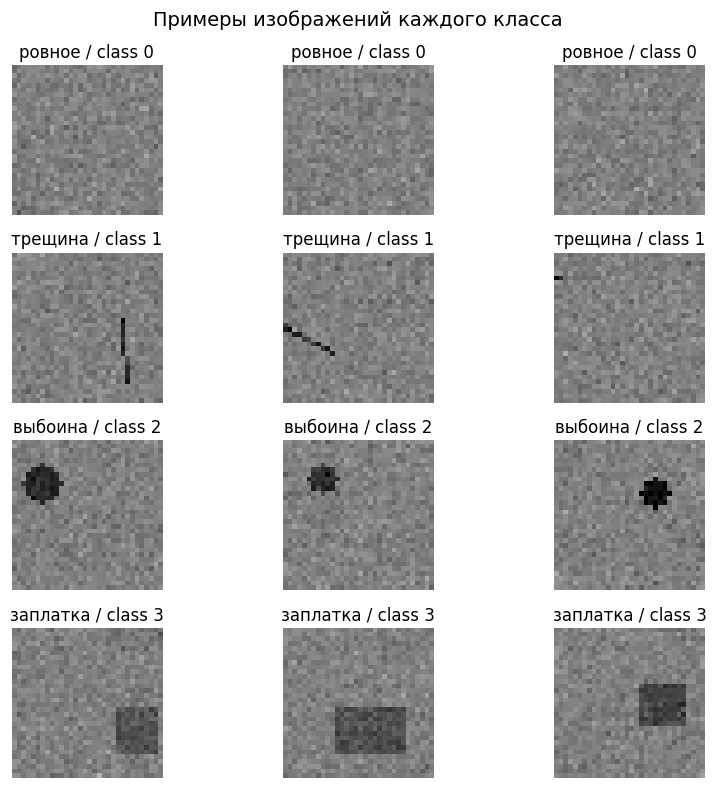

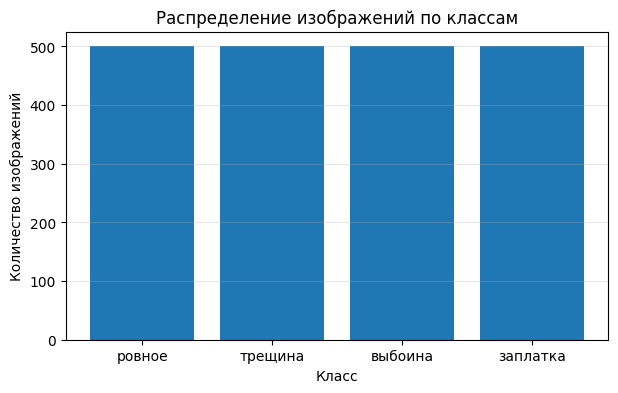

Выборка сбалансирована (каждый класс представлен одинаковым числом изображений).


In [ ]:
print("Форма X:", X.shape)
print("Форма y:", y.shape)
print("Тип X:", type(X))
print("Тип элементов X:", X.dtype)
print("Тип элементов y:", y.dtype)

print("\nДиапазон значений пикселей:")
print("min =", X.min())
print("max =", X.max())
print("mean =", X.mean())
print("std =", X.std())

class_counts = np.bincount(y, minlength=NUM_CLASSES)

print("\nРаспределение по классам:")
for class_id, count in enumerate(class_counts):
    print(f"{class_id} ({CLASS_NAMES[class_id]}): {count}")

# по 3 примера каждого класса
examples_per_class = 3

fig, axes = plt.subplots(NUM_CLASSES, examples_per_class, figsize=(9, 8))

for class_id in range(NUM_CLASSES):
    class_indices = np.where(y == class_id)[0]
    selected_indices = class_indices[:examples_per_class]

    for j, idx in enumerate(selected_indices):
        ax = axes[class_id, j]
        ax.imshow(X[idx], cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"{CLASS_NAMES[class_id]} / class {class_id}")
        ax.axis("off")

plt.suptitle("Примеры изображений каждого класса", fontsize=14)
plt.tight_layout()
plt.show()

# Barchart распределения классов
plt.figure(figsize=(7, 4))
plt.bar(CLASS_NAMES, class_counts)
plt.xlabel("Класс")
plt.ylabel("Количество изображений")
plt.title("Распределение изображений по классам")
plt.grid(axis="y", alpha=0.3)
plt.show()

if np.all(class_counts == class_counts[0]):
    print("Выборка сбалансирована (каждый класс представлен одинаковым числом изображений).")
else:
    print("Выборка несбалансирована (классы представлены разным числом изображений).")


Значения пикселей лежат в диапазоне [0, 1] поэтому данные уже имеют корректный численный масштаб.

- Среднее значение mean $\approx 0.485$ близко к уровню серого фона $0.5$

- Стандартное отклонение std $\approx 0.083$ показывает умеренный разброс яркости.

Выборка сбалансирована потому что каждый класс представлен 500 изображениями, поэтому accuracy можно интерпретировать без существенного смещения в сторону более частого класса.

Визуально классы различимы по геометрии дефекта. Трещина выглядит как тонкая линия, выбоина - округлое пятно, заплатка - прямоугольная область.  

Наиболее трудными могут быть случаи со слабой или маленькой трещиной, поскольку такой дефект занимает мало пикселей и может сливаться с шумом фона.

## Подготовка данных и baseline на простейшей сети

### Зачем
Baseline - это нижняя граница качества. Если сложный CNN не бьет простую MLP, значит, где-то ошибка
(переобучение, неправильная нормализация, утечка данных).

### Что нужно сделать
1. **Разобъем train/val/test** в пропорции 70/15/15 со `stratify=y` и зафиксированным seed.

2. **Нормализация:** вычтитаем среднее и поделим на std, рассчитанные **только на train**.

3. **Создаем `DataLoader`** для train/val/test с `batch_size = BATCH_SIZE`.

4. **Построим MLP-baseline** на «расплющенных» пикселях
  достаточно `Linear(1024, 128) → ReLU → Linear(128, 64) → ReLU → Linear(64, 4)`.

5. **Обучим** ровно `MAX_EPOCHS` эпох с помощью `train_model`. Построим кривые через `plot_curves`.

6. **Получим метрики на тесте** через `evaluate` + `classification_report`.

Размеры выборок:
Train: (1400, 32, 32) (1400,)
Val:   (300, 32, 32) (300,)
Test:  (300, 32, 32) (300,)

Распределение классов:
Train: [350 350 350 350]
Val:   [75 75 75 75]
Test:  [75 75 75 75]

Параметры нормализации, рассчитанные только на train:
train_mean = 0.48544723
train_std  = 0.083038636

После нормализации:
X_train_norm mean = -2.4261537e-06
X_train_norm std  = 0.99999994

Форма данных для MLP:
X_train_mlp: (1400, 1024)
X_val_mlp:   (300, 1024)
X_test_mlp:  (300, 1024)

MLP-baseline:
MLPBaseline(
  (net): Sequential(
    (0): Linear(in_features=1024, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)
epoch  1 | train_loss=1.0091 val_loss=0.7067 | train_acc=0.532 val_acc=0.647
epoch  2 | train_loss=0.5647 val_loss=0.6069 | train_acc=0.766 val_acc=0.697
epoch  3 | train_loss=0.3725 val_loss=0.5546 | train_acc=0.856 val_acc=0.757
epoch  4 | trai

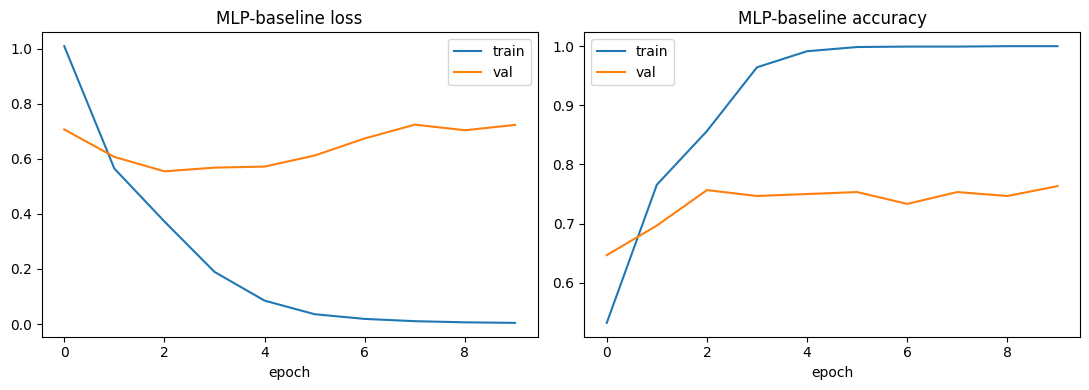


Classification report для MLP на test:
              precision    recall  f1-score   support

      ровное       0.69      0.91      0.78        75
     трещина       0.82      0.53      0.65        75
     выбоина       0.69      0.71      0.70        75
    заплатка       0.73      0.73      0.73        75

    accuracy                           0.72       300
   macro avg       0.73      0.72      0.71       300
weighted avg       0.73      0.72      0.71       300

Confusion matrix для MLP на test:
[[68  7  0  0]
 [31 40  4  0]
 [ 0  2 53 20]
 [ 0  0 20 55]]


In [ ]:
# разбиваем на train/val/test в пропорции 70/15/15 со stratify=y
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Размеры выборок:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

print("\nРаспределение классов:")
print("Train:", np.bincount(y_train, minlength=NUM_CLASSES))
print("Val:  ", np.bincount(y_val, minlength=NUM_CLASSES))
print("Test: ", np.bincount(y_test, minlength=NUM_CLASSES))


# нормализация где mean и std считаются только на train
train_mean = X_train.mean()
train_std = X_train.std()

X_train_norm = (X_train - train_mean) / train_std
X_val_norm = (X_val - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

print("\nПараметры нормализации, рассчитанные только на train:")
print("train_mean =", train_mean)
print("train_std  =", train_std)

print("\nПосле нормализации:")
print("X_train_norm mean =", X_train_norm.mean())
print("X_train_norm std  =", X_train_norm.std())


# подготовка данных для MLP раскрываем изображение в вектор 32x32 -> 1024
X_train_mlp = X_train_norm.reshape(len(X_train_norm), -1)
X_val_mlp = X_val_norm.reshape(len(X_val_norm), -1)
X_test_mlp = X_test_norm.reshape(len(X_test_norm), -1)

print("\nФорма данных для MLP:")
print("X_train_mlp:", X_train_mlp.shape)
print("X_val_mlp:  ", X_val_mlp.shape)
print("X_test_mlp: ", X_test_mlp.shape)


# преобразование в torch.Tensor
X_train_tensor = torch.tensor(X_train_mlp, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_mlp, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_mlp, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


# DataLoader для train/val/test
train_loader_mlp = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True # отдельно TRUE для устойчивости обучения
)

val_loader_mlp = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_mlp = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)


# MLP бейз (модель взяла как в условии)
class MLPBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IMG_SIZE * IMG_SIZE, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, NUM_CLASSES)
        )

    def forward(self, x):
        return self.net(x)


mlp_model = MLPBaseline()
print("\nMLP-baseline:")
print(mlp_model)


# обучение MLP при MAX_EPOCHS
mlp_history = train_model(
    mlp_model,
    train_loader_mlp,
    val_loader_mlp,
    epochs=MAX_EPOCHS,
    lr=LEARNING_RATE
)

plot_curves(mlp_history, title="MLP-baseline")


# оценка на test
y_true_mlp, y_pred_mlp = evaluate(mlp_model, test_loader_mlp)

print("\nClassification report для MLP на test:")
print(classification_report(
    y_true_mlp,
    y_pred_mlp,
    target_names=CLASS_NAMES
))

print("Confusion matrix для MLP на test:")
mlp_cm = confusion_matrix(y_true_mlp, y_pred_mlp)
print(mlp_cm)


**Вывод по MLP бейзлайну**

MLP-baseline показала на тестовой выборке
- `accuracy = 0.72`;
- `macro F1-score = 0.71`.

По графикам видно переобучение, потому что train accuracy достигает `1.0`, а validation accuracy остается около `0.75`, при этом validation loss после первых эпох начинает расти.

MLP не оптимальна для изображений, потому что после flatten картинка `32×32` превращается в вектор из 1024 пикселей и модель не использует явно двумерную структуру, локальность и форму дефекта.

По confusion matrix видно, что MLP чаще всего путает трещины с ровным покрытием (31 из 75 изображений класса «трещина» были отнесены к классу «ровное»). Как и предполагалось ранее:)

Также заметна взаимная путаница между выбоинами и заплатками. Здесь 20 выбоин классифицированы как заплатки, и 20 заплаток как выбоины.

Вероятно причина ошибок в том, что трещина занимает мало пикселей и может сливаться с шумом, а выбоина и заплатка обе выглядят как локальные темные области, различающиеся главным образом геометрической формой (нужна нейросеть которая сможет работать с геометрией).

## Задание 3. Сверточная модель и анализ переобучения

### Зачем
CNN встраивает в архитектуру предположение о локальности и трансляционной инвариантности признаков
(край, угол, текстура — где бы они ни оказались на картинке).

### Что нужно сделать

1. **Базовая CNN.** Минимальная архитектура (можно использовать как есть):
   ```
   Conv2d(1, 16, 3, padding=1) → ReLU → MaxPool(2)
   Conv2d(16, 32, 3, padding=1) → ReLU → MaxPool(2)
   Flatten → Linear(32*8*8, 64) → ReLU → Linear(64, 4)
   ```

2. **Две модификации**:
   - **глубже** — добавить еще один conv-блок;
   - **шире** — увеличить число фильтров вдвое;
   - **с BatchNorm** — добавить BatchNorm после сверток;
   - **другое ядро** — 5×5 вместо 3×3.

3. **Обучим все три модели** через `train_model` (10 эпох, batch=64). Построим кривые `plot_curves`
   для каждой и **визуально определим**, есть ли переобучение.

4. **Сводная таблица**:

   | Модель | # параметров | test accuracy | test F1-macro |
   |--------|--------------|---------------|---------------|
   | MLP | ... | ... | ... |
   | CNN базовая | ... | ... | ... |
   | CNN модификация 1 | ... | ... | ... |
   | CNN модификация 2 | ... | ... | ... |


In [ ]:
# подготовка данных для CNN
# было (N, 32, 32), нужно (N, 1, 32, 32)

X_train_cnn = X_train_norm[:, None, :, :]
X_val_cnn = X_val_norm[:, None, :, :]
X_test_cnn = X_test_norm[:, None, :, :]

print("Форма данных для CNN:")
print("X_train_cnn:", X_train_cnn.shape)
print("X_val_cnn:  ", X_val_cnn.shape)
print("X_test_cnn: ", X_test_cnn.shape)

X_train_cnn_tensor = torch.tensor(X_train_cnn, dtype=torch.float32)
X_val_cnn_tensor = torch.tensor(X_val_cnn, dtype=torch.float32)
X_test_cnn_tensor = torch.tensor(X_test_cnn, dtype=torch.float32)

train_loader_cnn = DataLoader(
    TensorDataset(X_train_cnn_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_cnn = DataLoader(
    TensorDataset(X_val_cnn_tensor, y_val_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_cnn = DataLoader(
    TensorDataset(X_test_cnn_tensor, y_test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)


Форма данных для CNN:
X_train_cnn: (1400, 1, 32, 32)
X_val_cnn:   (300, 1, 32, 32)
X_test_cnn:  (300, 1, 32, 32)


In [ ]:
# подсчет параметров нейросети для таблицы
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

**Базовая CNN**

In [ ]:
# базовая CNN из условия
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


basic_cnn = BasicCNN()

print("Базовая CNN:")
print(basic_cnn)
print("Число параметров:", count_parameters(basic_cnn))

Базовая CNN:
BasicCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Число параметров: 136196


**Модификация 1 - более широкая CNN**

Число сверточных фильтров увеличивается вдвое по сравнению с базовой моделью. Такая архитектура может извлекать больше различных локальных признаков изображения (например линии разных направлений, края, пятна и прямоугольные области), что потенциально полезно для умения различить трещины, выбоини и заплатки.

In [ ]:
# модификация 1
class WideCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


wide_cnn = WideCNN()

print("WideCNN:")
print(wide_cnn)
print("Число параметров:", count_parameters(wide_cnn))

WideCNN:
WideCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Число параметров: 281284


**Модификация 2 - CNN с BatchNorm**

BatchNorm нормализует промежуточные карты признаков и может сделать обучение более стабильным путем уменьшения чувствительности модели к масштабу активаций. Эта модификация не меняет основную идею базовой CNN, но проверяет, поможет ли стабилизация внутренних представлений улучшить качество и поведение train/validation кривых.

In [ ]:
# модификация 2
class BatchNormCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


batchnorm_cnn = BatchNormCNN()

print("\nBatchNormCNN:")
print(batchnorm_cnn)
print("Число параметров:", count_parameters(batchnorm_cnn))


BatchNormCNN:
BatchNormCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Число параметров: 136292


**Обучение трех моделей**

--- BasicCNN ---
epoch  1 | train_loss=1.0312 val_loss=0.7372 | train_acc=0.534 val_acc=0.620
epoch  2 | train_loss=0.5897 val_loss=0.4977 | train_acc=0.735 val_acc=0.790
epoch  3 | train_loss=0.4194 val_loss=0.3563 | train_acc=0.826 val_acc=0.857
epoch  4 | train_loss=0.3035 val_loss=0.3345 | train_acc=0.889 val_acc=0.837
epoch  5 | train_loss=0.2302 val_loss=0.2411 | train_acc=0.920 val_acc=0.917
epoch  6 | train_loss=0.1683 val_loss=0.2122 | train_acc=0.949 val_acc=0.927
epoch  7 | train_loss=0.1497 val_loss=0.2245 | train_acc=0.958 val_acc=0.907
epoch  8 | train_loss=0.1270 val_loss=0.2549 | train_acc=0.959 val_acc=0.893
epoch  9 | train_loss=0.1347 val_loss=0.2513 | train_acc=0.959 val_acc=0.897
epoch 10 | train_loss=0.0951 val_loss=0.1963 | train_acc=0.971 val_acc=0.923


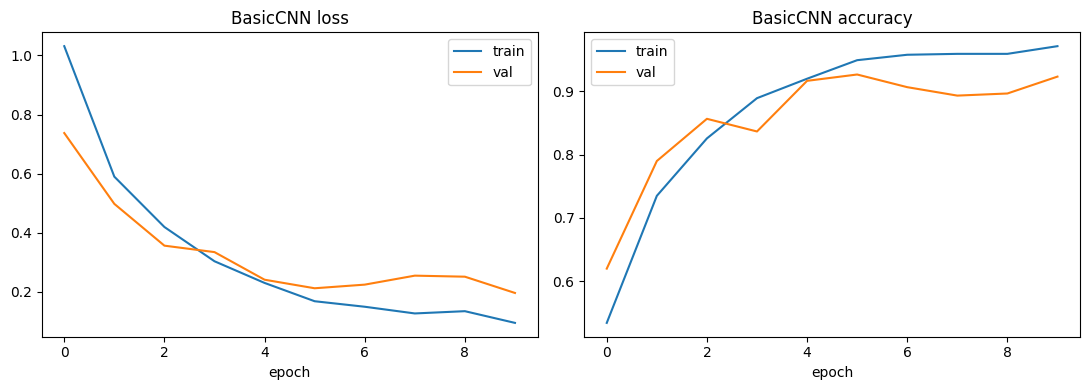

--- WideCNN ---
epoch  1 | train_loss=0.9811 val_loss=0.5802 | train_acc=0.550 val_acc=0.740
epoch  2 | train_loss=0.4969 val_loss=0.3714 | train_acc=0.794 val_acc=0.857
epoch  3 | train_loss=0.2731 val_loss=0.2903 | train_acc=0.908 val_acc=0.887
epoch  4 | train_loss=0.1773 val_loss=0.2034 | train_acc=0.943 val_acc=0.930
epoch  5 | train_loss=0.1427 val_loss=0.2575 | train_acc=0.952 val_acc=0.890
epoch  6 | train_loss=0.1122 val_loss=0.1239 | train_acc=0.964 val_acc=0.963
epoch  7 | train_loss=0.0497 val_loss=0.1037 | train_acc=0.990 val_acc=0.973
epoch  8 | train_loss=0.0430 val_loss=0.1397 | train_acc=0.989 val_acc=0.950
epoch  9 | train_loss=0.0418 val_loss=0.1035 | train_acc=0.988 val_acc=0.977
epoch 10 | train_loss=0.0443 val_loss=0.1366 | train_acc=0.984 val_acc=0.967


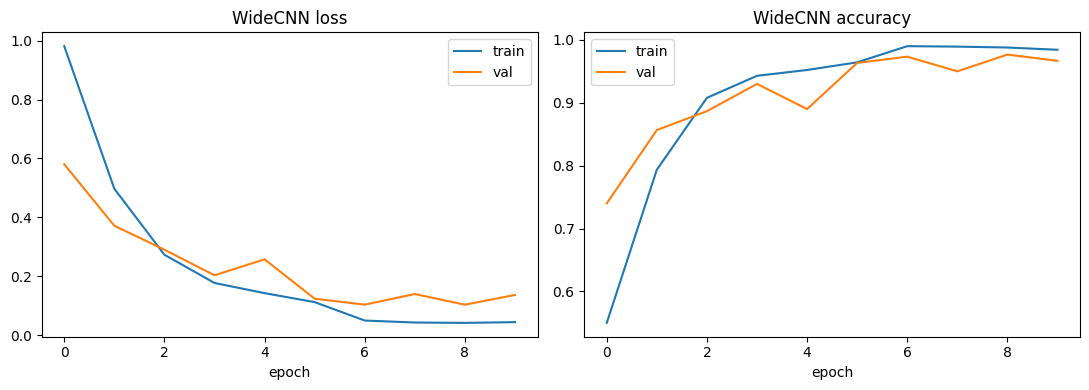

--- BatchNormCNN ---
epoch  1 | train_loss=0.9982 val_loss=0.6909 | train_acc=0.531 val_acc=0.773
epoch  2 | train_loss=0.4682 val_loss=0.6687 | train_acc=0.869 val_acc=0.687
epoch  3 | train_loss=0.2690 val_loss=0.4614 | train_acc=0.928 val_acc=0.757
epoch  4 | train_loss=0.1607 val_loss=0.1946 | train_acc=0.969 val_acc=0.937
epoch  5 | train_loss=0.1372 val_loss=0.1725 | train_acc=0.961 val_acc=0.937
epoch  6 | train_loss=0.0969 val_loss=0.1335 | train_acc=0.979 val_acc=0.950
epoch  7 | train_loss=0.0865 val_loss=0.1214 | train_acc=0.980 val_acc=0.947
epoch  8 | train_loss=0.0607 val_loss=0.1060 | train_acc=0.986 val_acc=0.970
epoch  9 | train_loss=0.0554 val_loss=0.1014 | train_acc=0.989 val_acc=0.957
epoch 10 | train_loss=0.0515 val_loss=0.1094 | train_acc=0.987 val_acc=0.947


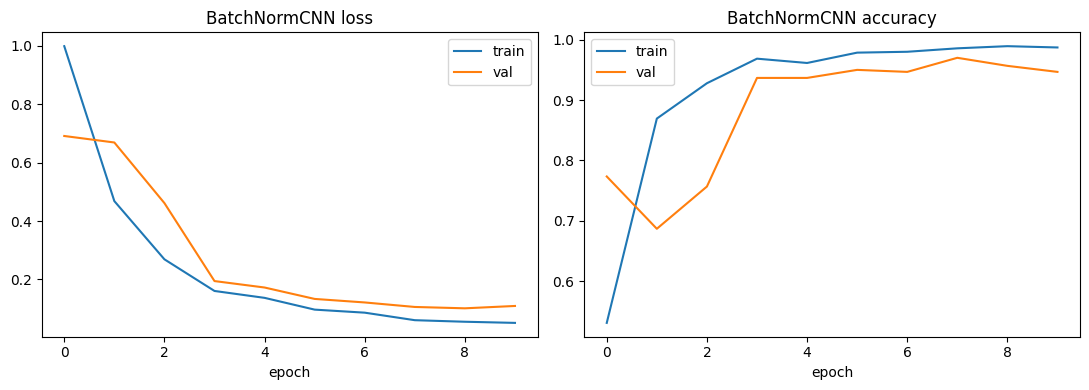

In [ ]:
# обучение базовой CNN
print("--- BasicCNN ---")
basic_history = train_model(
    basic_cnn,
    train_loader_cnn,
    val_loader_cnn,
    epochs=MAX_EPOCHS,
    lr=LEARNING_RATE
)

plot_curves(basic_history, title="BasicCNN")


# обучение широкой CNN
print("--- WideCNN ---")
wide_history = train_model(
    wide_cnn,
    train_loader_cnn,
    val_loader_cnn,
    epochs=MAX_EPOCHS,
    lr=LEARNING_RATE
)

plot_curves(wide_history, title="WideCNN")


# обучение CNN с BatchNorm
print("--- BatchNormCNN ---")
batchnorm_history = train_model(
    batchnorm_cnn,
    train_loader_cnn,
    val_loader_cnn,
    epochs=MAX_EPOCHS,
    lr=LEARNING_RATE
)

plot_curves(batchnorm_history, title="BatchNormCNN")

**Сводная таблица**

In [ ]:
import pandas as pd

summary_rows = []

# MLP из задания 2
y_true_mlp, y_pred_mlp = evaluate(mlp_model, test_loader_mlp)

mlp_report = classification_report(
    y_true_mlp,
    y_pred_mlp,
    target_names=CLASS_NAMES,
    output_dict=True
)

summary_rows.append({
    "Модель": "MLP (из задания 2)",
    "# параметров": count_parameters(mlp_model),
    "test accuracy": mlp_report["accuracy"],
    "test F1-macro": mlp_report["macro avg"]["f1-score"]
})


# CNN базовая
y_true_basic, y_pred_basic = evaluate(basic_cnn, test_loader_cnn)

basic_report = classification_report(
    y_true_basic,
    y_pred_basic,
    target_names=CLASS_NAMES,
    output_dict=True
)

summary_rows.append({
    "Модель": "CNN базовая",
    "# параметров": count_parameters(basic_cnn),
    "test accuracy": basic_report["accuracy"],
    "test F1-macro": basic_report["macro avg"]["f1-score"]
})


# CNN модификация 1: WideCNN
y_true_wide, y_pred_wide = evaluate(wide_cnn, test_loader_cnn)

wide_report = classification_report(
    y_true_wide,
    y_pred_wide,
    target_names=CLASS_NAMES,
    output_dict=True
)

summary_rows.append({
    "Модель": "CNN модификация 1: WideCNN",
    "# параметров": count_parameters(wide_cnn),
    "test accuracy": wide_report["accuracy"],
    "test F1-macro": wide_report["macro avg"]["f1-score"]
})


# CNN модификация 2: BatchNormCNN
y_true_batchnorm, y_pred_batchnorm = evaluate(batchnorm_cnn, test_loader_cnn)

batchnorm_report = classification_report(
    y_true_batchnorm,
    y_pred_batchnorm,
    target_names=CLASS_NAMES,
    output_dict=True
)

summary_rows.append({
    "Модель": "CNN модификация 2: BatchNormCNN",
    "# параметров": count_parameters(batchnorm_cnn),
    "test accuracy": batchnorm_report["accuracy"],
    "test F1-macro": batchnorm_report["macro avg"]["f1-score"]
})


summary_df = pd.DataFrame(summary_rows)

summary_df["test accuracy"] = summary_df["test accuracy"].round(3)
summary_df["test F1-macro"] = summary_df["test F1-macro"].round(3)

summary_df

,Модель,# параметров,test accuracy,test F1-macro
0,MLP (из задания 2),139716,0.720,0.714
1,CNN базовая,136196,0.943,0.943
2,CNN модификация 1: WideCNN,281284,0.973,0.973
3,CNN модификация 2: BatchNormCNN,136292,0.957,0.957


**Вывод**

Лучшей моделью по качеству на тестовой выборке оказалась `WideCNN`:
- test accuracy = 0.973
- test F1-macro = 0.973.

Это заметно лучше MLP baseline (accuracy = 0.72) и базовой CNN (accuracy = 0.943).

> В этом видно пользу сверточной архитектуры для изображений, потому что CNN сохраняет пространственную структуру картинки и извлекает локальные признаки дефектов.

Из двух модификаций больший эффект дала также `WideCNN`. Увеличение числа фильтров позволило модели извлекать больше разных локальных паттернов. Это соответствует природе данных, где классы отличаются именно *геометрической* формой дефекта.

У моделей есть признаки умеренного переобучения.
- Признаки переобучения наиболее заметны у BasicCNN - после нескольких эпох train_loss продолжает снижаться, а val_loss на отдельных участках начинает расти.
- У WideCNN также есть небольшие признаки переобучения - train loss почти монотонно падает до очень малых значений, а validation loss после достижения минимума начинает колебаться и немного увеличиваться к 10-й эпохе.

- У BatchNormCNN переобучение выражено слабее ( train loss снижается, а validation loss в целом тоже уменьшается и затем стабилизируется ).

С точки зрения компромисса «качество vs число параметров» усложнение архитектуры до WideCNN оказалось оправданным: число параметров выросло с 136196 до 281284, но test accuracy увеличилась с 0.943 до 0.973. Модификация с BatchNorm добавила совсем мало параметров и тоже улучшила качество относительно базовой CNN, но уступила широкой модели.

Поэтому в данной задаче наиболее удачным вариантом является `WideCNN` так как даёт максимальное качество классификации.

## Регуляризация и устойчивость модели

### Зачем
Регуляризация снижает переобучение и делает модель устойчивее к небольшим изменениям входа.

### Что нужно сделать

1. Возьмем **лучшую CNN**.

2. Добавим **несколько** из следующих механизмов:

   | Метод | Где применять |
   |-------|---------------|
   | **Dropout** (`p=0.3–0.5`) | после ReLU перед последним Linear |
   | **Weight decay (L2)** | параметр `weight_decay` у `train_model` (`1e-4` … `1e-3`) |
   | **Batch Normalization** | после conv-слоев  |
   | **Аугментация** (горизонтальный flip и/или небольшой шум) | в `__getitem__`  `Dataset` или прямо в train loop |

3. **Обучим** регуляризованную модель (10 эпох, batch=64) и построим кривые.

4. **Сравним «без регуляризации» vs «с регуляризацией»** в одной таблице:

   | Модель | train acc | val acc | test acc | gap (train − val) |
   |--------|-----------|---------|----------|-------------------|
   | CNN без регуляризации | ... | ... | ... | ... |
   | CNN с регуляризацией | ... | ... | ... | ... |


Лучшая CNN из задания 3 - `WideCNN`.

Цель регуляризации не только попытаться улучшить test accuracy (хотя 0.977 уже очень высокая), но и сделать обучение более устойчивым и уменьшить разрыв между train и validation accuracy.

---

**Регуляризация 1 - Dropout(p=0.3)**

Dropout случайно зануляет часть признаков во время обучения, поэтому модель не может слишком сильно полагаться на отдельные нейроны классификатора и хуже запоминает частные особенности train-выборки.

---
**Регуляризация 2 - weight_decay=1e-4**

L2-регуляризация штрафует слишком большие значения параметров и тем самым делает модель более простой и устойчивой. Такой вариант особенно хорош для `WideCNN`, потому что она имеет больше параметров и поэтому потенциально сильнее склонна к переобучению.


RegularizedWideCNN:
RegularizedWideCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)
Число параметров: 281284

--- RegularizedWideCNN ---
epoch  1 | train_loss=1.0921 val_loss=0.6720 | train_acc=0.448 val_acc=0.750
epoch  2 | train_loss=0.6273 val_loss=0.4155 | train_acc=0.711 val_acc=0.823
epoch  3 | train_loss=0.4075 val_loss=0.2741 | train_acc=0.841 val_acc=0.913
epoch  4 | train_loss=0.2653 val_loss=0.2157 

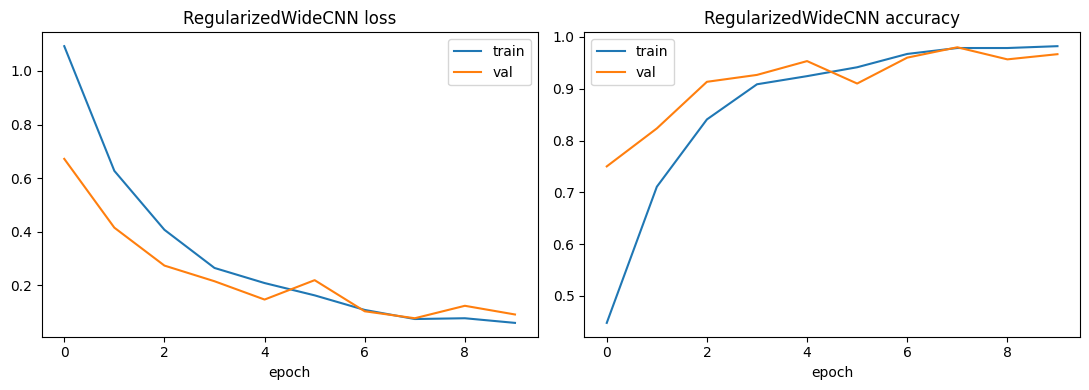

In [ ]:
# зафииксируем случайность перед созданием и обучением регуляризованной модели
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

class RegularizedWideCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


regularized_wide_cnn = RegularizedWideCNN()

print("RegularizedWideCNN:")
print(regularized_wide_cnn)
print("Число параметров:", count_parameters(regularized_wide_cnn))


print("\n--- RegularizedWideCNN ---")
regularized_wide_history = train_model(
    regularized_wide_cnn,
    train_loader_cnn,
    val_loader_cnn,
    epochs=MAX_EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

plot_curves(regularized_wide_history, title="RegularizedWideCNN")


In [ ]:
# таблица сравнения WideCNN без регуляризации vs WideCNN с регуляризацией

# CNN без регуляризации
y_true_wide, y_pred_wide = evaluate(wide_cnn, test_loader_cnn)

wide_report = classification_report(
    y_true_wide,
    y_pred_wide,
    target_names=CLASS_NAMES,
    output_dict=True
)

wide_train_acc = wide_history["train_acc"][-1]
wide_val_acc = wide_history["val_acc"][-1]
wide_test_acc = wide_report["accuracy"]
wide_gap = wide_train_acc - wide_val_acc


# CNN с регуляризацией
y_true_reg, y_pred_reg = evaluate(regularized_wide_cnn, test_loader_cnn)

reg_report = classification_report(
    y_true_reg,
    y_pred_reg,
    target_names=CLASS_NAMES,
    output_dict=True
)

reg_train_acc = regularized_wide_history["train_acc"][-1]
reg_val_acc = regularized_wide_history["val_acc"][-1]
reg_test_acc = reg_report["accuracy"]
reg_gap = reg_train_acc - reg_val_acc


regularization_summary = pd.DataFrame([
    {
        "Модель": "CNN без регуляризации",
        "train acc": wide_train_acc,
        "val acc": wide_val_acc,
        "test acc": wide_test_acc,
        "gap (train − val)": wide_gap
    },
    {
        "Модель": "CNN с регуляризацией",
        "train acc": reg_train_acc,
        "val acc": reg_val_acc,
        "test acc": reg_test_acc,
        "gap (train − val)": reg_gap
    }
])

regularization_summary[["train acc", "val acc", "test acc", "gap (train − val)"]] = (
    regularization_summary[["train acc", "val acc", "test acc", "gap (train − val)"]]
    .round(3)
)

regularization_summary

,Модель,train acc,val acc,test acc,gap (train − val)
0,CNN без регуляризации,0.984,0.967,0.973,0.018
1,CNN с регуляризацией,0.982,0.967,0.983,0.015


**Вывод**

После добавления регуляризации gap между train и validation accuracy уменьшился с 0.018 до 0.015, то есть разрыв между качеством на обучающей и валидационной выборках стал меньше. При этом test accuracy вырос с 0.973 до 0.983, поэтому регуляризация еще и дополнительно улучшила обобщающую способность модели.

В регуляризованной модели использовалась комбинация Dropout(p=0.3) и weight_decay=1e-4. Dropout мешает модели слишком сильно полагаться на отдельные признаки перед последним линейным слоем, а weight decay штрафует слишком большие веса, поэтому вместе эти методы делают модель более устойчивой.

Для задачи дорожных дефектов вредными могут быть слишком сильное размытие, сильный шум и в какой то степени вертикальный flip. Сильное размытие может стереть тонкие трещины, сильный шум может замаскировать локальные темные дефекты. Что касается вертикального flip-а то может быть нежелателен в реальных данных, если ориентация камеры и дороги несет смысл.

## Сравнение моделей. Интерпретация и презентация результатов


**Сводная таблица всех моделей**

In [ ]:
# лучшая модель по результатам
best_model = regularized_wide_cnn
best_model_name = "RegularizedWideCNN"

final_rows = []

models_for_summary = [
    ("MLP", mlp_model, test_loader_mlp),
    ("CNN базовая", basic_cnn, test_loader_cnn),
    ("CNN модификация 1: WideCNN", wide_cnn, test_loader_cnn),
    ("CNN модификация 2: BatchNormCNN", batchnorm_cnn, test_loader_cnn),
    ("CNN с регуляризацией: RegularizedWideCNN", regularized_wide_cnn, test_loader_cnn),
]

for model_name, model, loader in models_for_summary:
    y_true_model, y_pred_model = evaluate(model, loader)

    report = classification_report(
        y_true_model,
        y_pred_model,
        target_names=CLASS_NAMES,
        output_dict=True
    )

    final_rows.append({
        "Модель": model_name,
        "# параметров": count_parameters(model),
        "test accuracy": report["accuracy"],
        "test F1-macro": report["macro avg"]["f1-score"]
    })

final_summary_df = pd.DataFrame(final_rows)

final_summary_df["test accuracy"] = final_summary_df["test accuracy"].round(3)
final_summary_df["test F1-macro"] = final_summary_df["test F1-macro"].round(3)

display(final_summary_df)

,Модель,# параметров,test accuracy,test F1-macro
0,MLP,139716,0.720,0.714
1,CNN базовая,136196,0.943,0.943
2,CNN модификация 1: WideCNN,281284,0.973,0.973
3,CNN модификация 2: BatchNormCNN,136292,0.957,0.957
4,CNN с регуляризацией: RegularizedWideCNN,281284,0.983,0.983


**Confusion matrix лучшей модели**

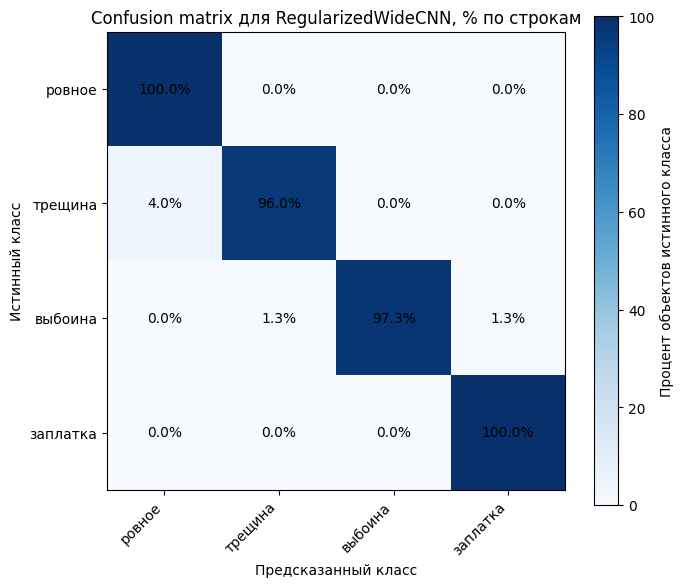

Чаще всего модель путает класс 'трещина' с классом 'ровное': 4.0% объектов этого истинного класса.


In [ ]:
# Confusion matrix лучшей модели

y_true_best, y_pred_best = evaluate(best_model, test_loader_cnn)

cm_best = confusion_matrix(y_true_best, y_pred_best)
cm_best_percent = cm_best / cm_best.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(7, 6))
plt.imshow(cm_best_percent, cmap="Blues", vmin=0, vmax=100)
plt.colorbar(label="Процент объектов истинного класса")

plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), CLASS_NAMES)

plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title(f"Confusion matrix для {best_model_name}, % по строкам")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j, i,
            f"{cm_best_percent[i, j]:.1f}%",
            ha="center",
            va="center",
            color="black"
        )

plt.tight_layout()
plt.show()

# находим самую частую пару путаницы вне диагонали
cm_offdiag = cm_best_percent.copy()
np.fill_diagonal(cm_offdiag, -1)

max_i, max_j = np.unravel_index(np.argmax(cm_offdiag), cm_offdiag.shape)

print(
    f"Чаще всего модель путает класс "
    f"'{CLASS_NAMES[max_i]}' с классом '{CLASS_NAMES[max_j]}': "
    f"{cm_best_percent[max_i, max_j]:.1f}% объектов этого истинного класса."
)

**Примеры ошибок**

Всего ошибок лучшей модели: 5
Ошибок с уверенностью softmax > 0.8: 3


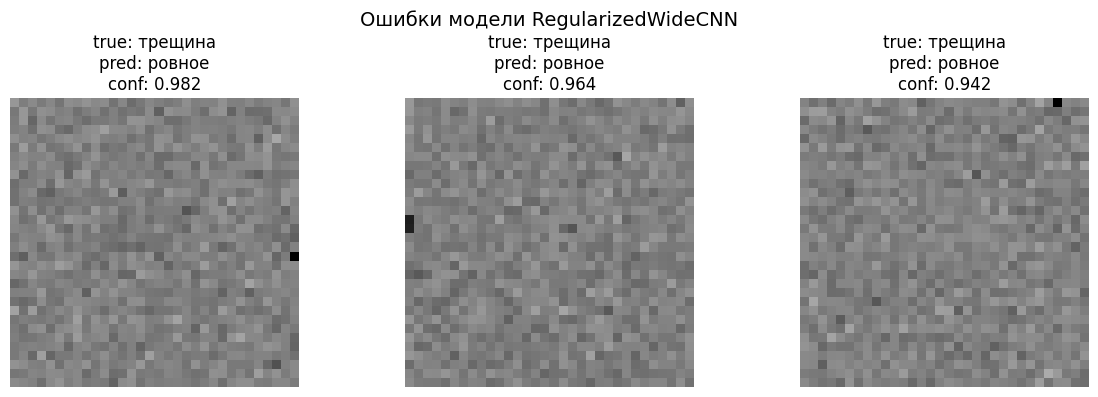

In [ ]:
# примеры ошибок с высокой уверенностью softmax > 0.8

@torch.no_grad()
def predict_with_confidence(model, loader):
    model.eval()
    all_true = []
    all_pred = []
    all_conf = []
    all_probs = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs = F.softmax(logits, dim=1)

        conf, pred = probs.max(dim=1)

        all_true.append(yb.numpy())
        all_pred.append(pred.cpu().numpy())
        all_conf.append(conf.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    return (
        np.concatenate(all_true),
        np.concatenate(all_pred),
        np.concatenate(all_conf),
        np.concatenate(all_probs)
    )


y_true_best, y_pred_best, conf_best, probs_best = predict_with_confidence(
    best_model,
    test_loader_cnn
)

error_mask = y_true_best != y_pred_best
high_conf_error_mask = error_mask & (conf_best > 0.8)

high_conf_error_indices = np.where(high_conf_error_mask)[0]

print(f"Всего ошибок лучшей модели: {error_mask.sum()}")
print(f"Ошибок с уверенностью softmax > 0.8: {len(high_conf_error_indices)}")

# если ошибок > 3 -  три самые уверенные
# если < 3 показываем сколько есть, недостающие заменяем наиболее уверенными ошибками
if len(high_conf_error_indices) >= 3:
    selected_error_indices = high_conf_error_indices[
        np.argsort(conf_best[high_conf_error_indices])[-3:][::-1]
    ]
else:
    all_error_indices = np.where(error_mask)[0]
    selected_error_indices = all_error_indices[
        np.argsort(conf_best[all_error_indices])[-min(3, len(all_error_indices)):][::-1]
    ]
    print(
        "Показаны самые уверенные ошибки из найденных."
    )

n_errors_to_show = len(selected_error_indices)

fig, axes = plt.subplots(1, n_errors_to_show, figsize=(4 * n_errors_to_show, 4))

if n_errors_to_show == 1:
    axes = [axes]

for ax, idx in zip(axes, selected_error_indices):
    true_class = y_true_best[idx]
    pred_class = y_pred_best[idx]
    confidence = conf_best[idx]

    ax.imshow(X_test[idx], cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(
        f"true: {CLASS_NAMES[true_class]}\n"
        f"pred: {CLASS_NAMES[pred_class]}\n"
        f"conf: {confidence:.3f}"
    )

plt.suptitle(f"Ошибки модели {best_model_name}", fontsize=14)
plt.tight_layout()
plt.show()

**Итоговый вывод проекта**

В качестве итоговой модели выбрана `RegularizedWideCNN`, так как она показала лучшее качество среди всех моделей проекта:
- test accuracy = 0.983
- test F1-macro = 0.983.

По сравнению с MLP качество выросло очень существенно, потому что CNN сохраняет пространственную структуру изображения и лучше извлекает локальные признаки дефектов. Регуляризация через Dropout(p=0.3) и weight_decay=1e-4 модель стала немного лучше обобщать на тестовую выборку.

По confusion matrix главная системная слабость модели - распознавание трещин (4.0% изображений класса «трещина» были ошибочно отнесены к классу «ровное»). Это подтверждается примерами ошибок с высокой уверенностью. Причина в том, что тонкая трещина занимает мало пикселей и может сливаться с шумным серым фоном.

Для дальнейшего развития системы я бы в первую очередь усилила/разнообразила данные для класса «трещина». Можно взять больше примеров коротких, слабоконтрастных и тонких трещин, а также аккуратные аугментации, которые не сотрут дефект. Дополнительно можно попробовать более чувствительную архитектуру или loss-функцию, которая сильнее штрафует пропуск опасных дефектов, потому что в реальной задаче перепутать трещину с ровным покрытием особенно нежелательно.